# Density Plots

DS 2023 | Communicating with Data

## Overview

:::{image}images/kde_plot.png
:width: 400px
:align: left
:::

A density plot is something like a continuous version of a histogram. 

Like a histogram, tt represents the distribution of a continuous variable. 

But instead of using binning and counting, it estimates a probability density function using more sophisticated methods, such as kernel estimation.

This function is represented a line graph, as opposed to a bar chart. 

A density plot may be thought of as a special case of a line graph where the x axis represents an increasing numeric value, and the y axis represents an estimate or frequency. However, the density plot does not represent a trend. Instead, it is more like the function use case.

Like line graphs, they may also be rendered as area charts to show accumulation.

## Use Cases

Like histograms, density plots provide a quick way to inspect the centrality and dispersion of a distribution.

They allow you to inspect the shape of a distribution for modality, skew, and kurtosis.

They can also surface outliers and mutliple populations.

Beyond histograms, density plots are more opiniated, as it were, in suggesting a function behind the empirical distribution. 

Instead of showing counts, it shows the denstity of data points within a given range. 

Density plots are particularly useful for larger datasets.

## Creating a density plot from scratch

Density plots are construced using a method called **kernel density estimation** (KDE). 

Hence their being called KDE plots, as in Pandas (see below).

The image below gives a good idea of how they are constructed.

For data point, a gaussian distribution is generated. These are the kernels.

Then, these kernels are added up to produce the emergent curve.

In practice the algorithm may be more complicated &mdash; for example the parameters of the kernals may vary &mdash; but this is the essential idea.

![](images/kde-method.png)

The plot above is produced by the following code.

This code shows clearly how the plot is constructed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Define 5 sample data points
data = np.array([1.5, 2.2, 3.0, 3.5, 5.0])

# 2. Create an x-axis grid for the curves
x = np.linspace(-1, 8, 400)

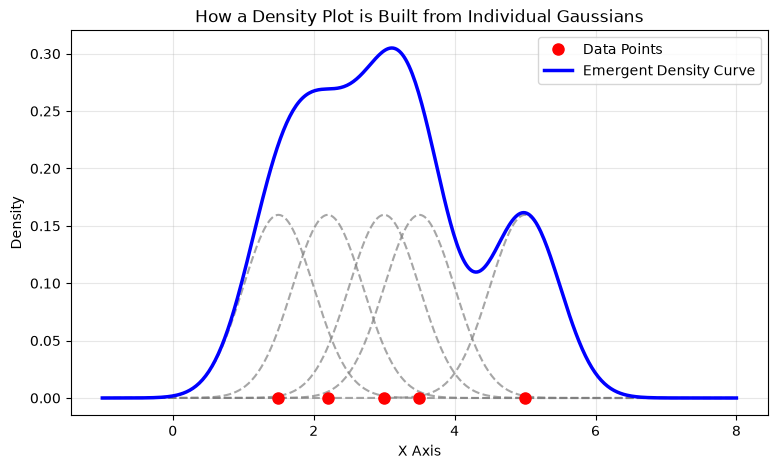

In [3]:
# 3. Set the bandwidth (width of each little Gaussian)
bandwidth = 0.5

# Create the canvas
plt.figure(figsize=(9, 5))

# 4. Plot the raw data points along the bottom axis (the "rug")
plt.plot(data, np.zeros_like(data), 'ro', markersize=8, label='Data Points', zorder=5)

# 5. Compute and plot individual Gaussians for each point
individual_gaussians = []
for point in data:
    
    # Standard formula for a Gaussian curve -- THE KERNEL
    gaussian = (1 / (bandwidth * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - point) / bandwidth) ** 2)
    
    # Scale down by total number of points so the cumulative area equals 1
    scaled_gaussian = gaussian / len(data)
    individual_gaussians.append(scaled_gaussian)
    
    # Plot each little curve as a dashed gray line
    plt.plot(x, scaled_gaussian, color='gray', linestyle='--', alpha=0.7)

# 6. Sum all the individual curves together to get the final line
emergent_density = np.sum(individual_gaussians, axis=0)

# Plot the final density curve
plt.plot(x, emergent_density, color='blue', linewidth=2.5, label='Emergent Density Curve')

# Formatting the graph
plt.title('How a Density Plot is Built from Individual Gaussians')
plt.xlabel('X Axis')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

# Display the plot
plt.show()

## Using Pandas KDE function

Let's use the data set we used in our discussion of Histograms.

In [4]:
healthexp = sns.load_dataset('healthexp')
healthexp.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


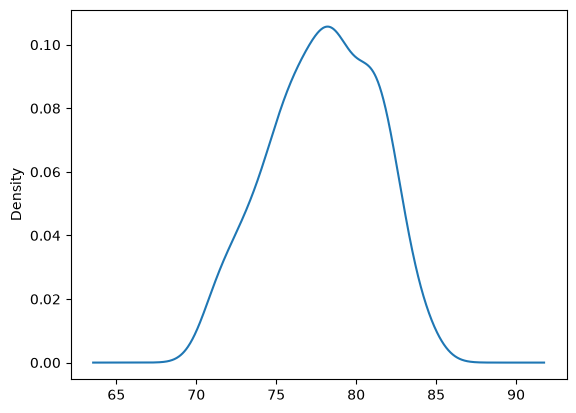

In [5]:
healthexp.Life_Expectancy.plot.kde()
plt.show()

In [6]:
life_exp_wide = healthexp.pivot(index='Year', columns='Country', values='Life_Expectancy')
life_exp_wide.head()

Country,Canada,France,Germany,Great Britain,Japan,USA
Year,,,,,,
1970,NaN,72.2,70.6,71.9,72.0,70.9
1971,72.8,NaN,70.8,71.9,72.9,71.2
1972,NaN,NaN,71.0,NaN,73.2,71.2
1973,NaN,NaN,71.3,NaN,73.4,71.4
1974,NaN,NaN,71.5,NaN,73.7,72.0


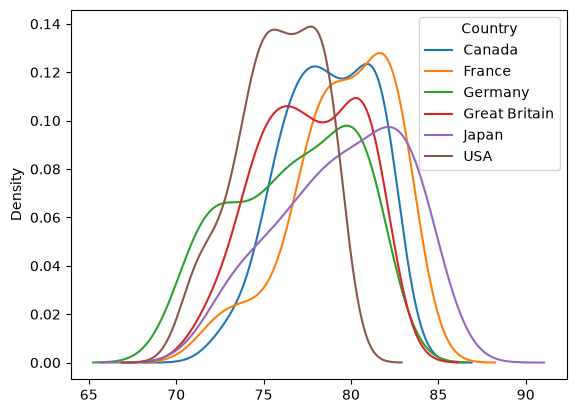

In [7]:
life_exp_wide.plot.kde()
plt.show()

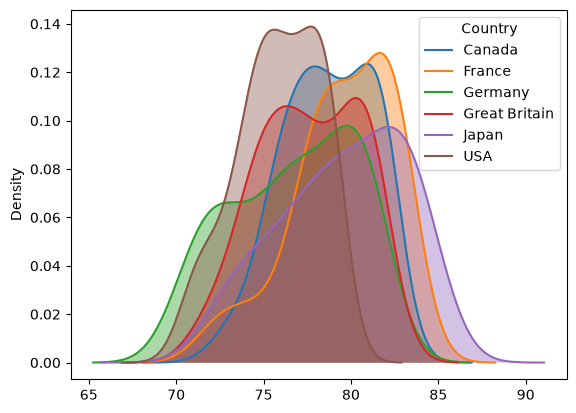

In [8]:
ax = life_exp_wide.plot.kde()
for line in ax.lines: 
    ax.fill_between(line.get_xdata(), line.get_ydata(), alpha=0.4)
plt.show()

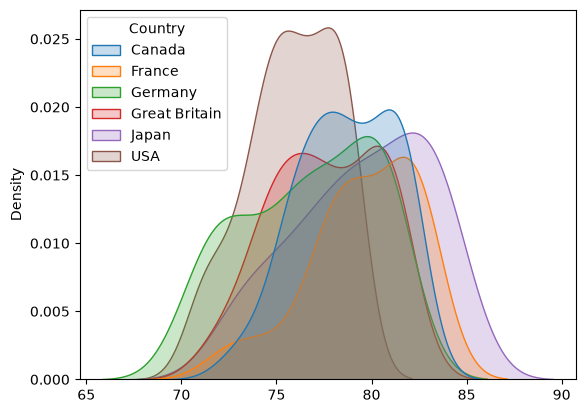

In [20]:
sns.kdeplot(life_exp_wide, fill=True)
plt.show()

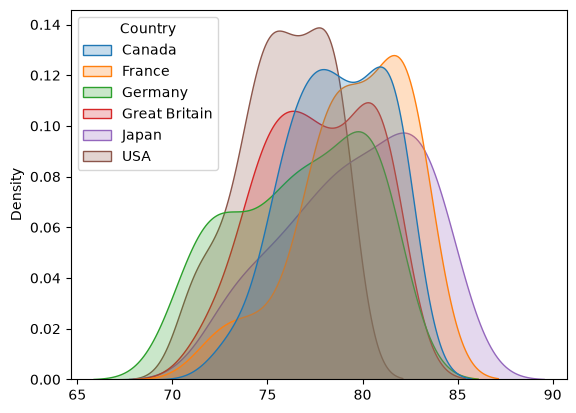

In [10]:
sns.kdeplot(life_exp_wide, fill=True, common_norm=False)
plt.show()

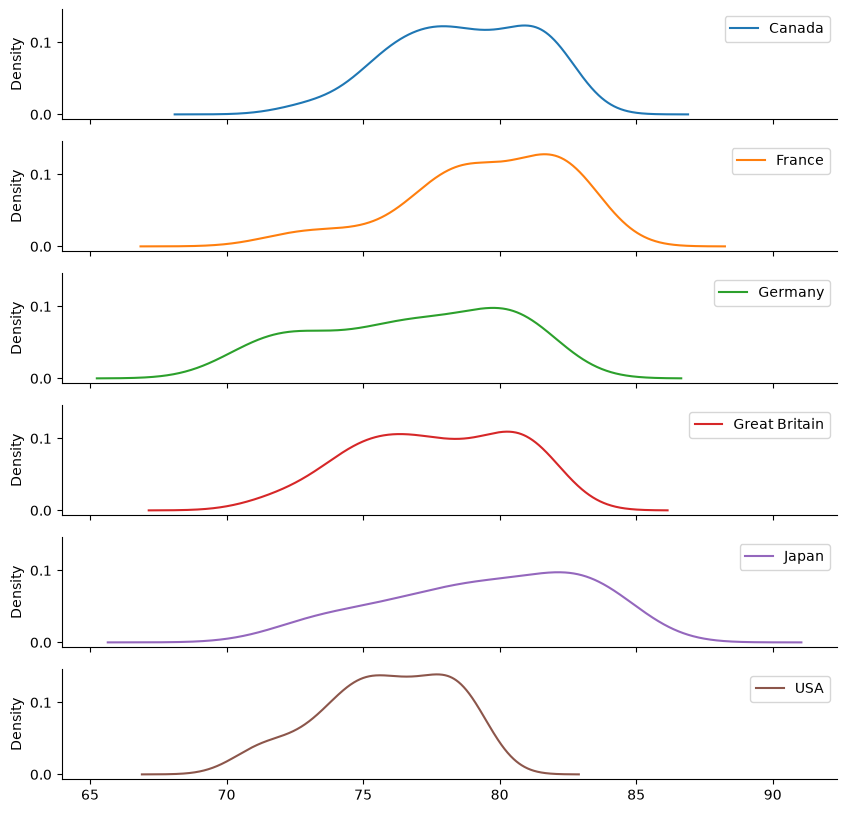

In [11]:
life_exp_wide.plot.kde(subplots=True, figsize=(10, 10), sharey=True)
sns.despine()
plt.show()

## Combining histograms and density plots

Data scientists sometimes hedge their bets and show both histograms and density plots at the same time.

One way to do this is to set `density = True` on the histogram and then plot both an the same axes object.

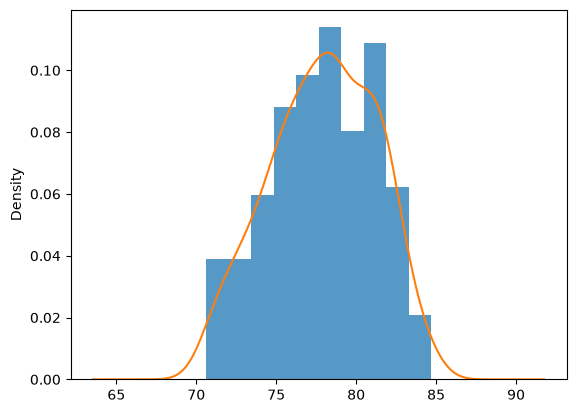

In [12]:
healthexp.Life_Expectancy.plot.hist(density=True, alpha=.75)
healthexp.Life_Expectancy.plot.kde()
plt.show()

Another pattern is to use `ax.twinx()`, as we did in our lesson on Line Graphs.

This preserves the y axis domains of both plots.

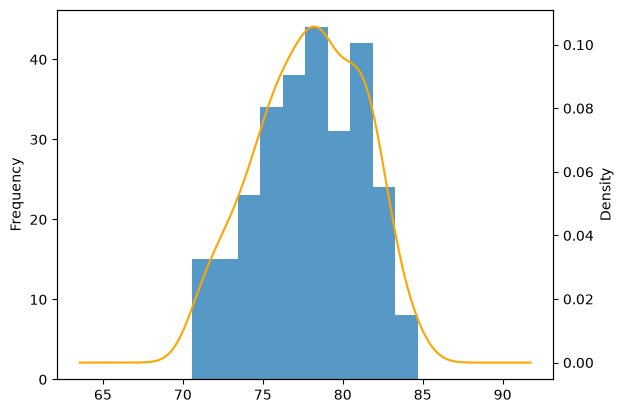

In [13]:
ax1 = healthexp.Life_Expectancy.plot.hist(alpha=.75)
ax2 = ax1.twinx()
healthexp.Life_Expectancy.plot.kde(ax=ax2, color='orange')
plt.show()

Note, however, the misalignment of the two axes. Even though they represent different domains, they should align at $0$.

Because density plots can be negative, the plotting function left some room for that.

To align the two axes, we force both y axes to be use $0$ as their bottom value.

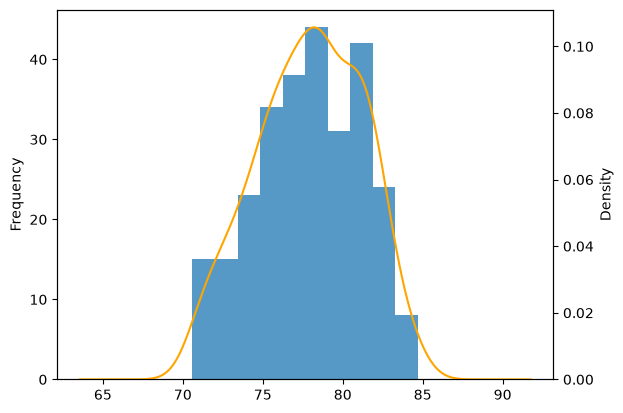

In [14]:
ax1 = healthexp.Life_Expectancy.plot.hist(alpha=.75)
ax2 = ax1.twinx()
healthexp.Life_Expectancy.plot.kde(ax=ax2, color='orange')
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
plt.show()

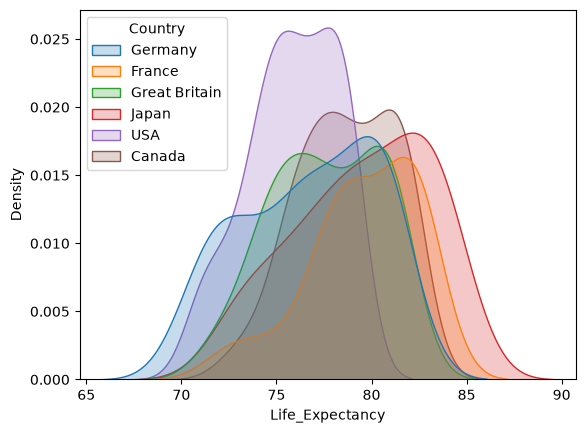

In [22]:
sns.kdeplot(healthexp, x='Life_Expectancy', hue='Country', fill=True)
plt.show()